# HEV Thermal Demo: Cold Start, Cold Ambient

This demo simulates a Hybrid Electric Vehicle (HEV) with thermal modeling under
cold start and cold ambient conditions, where the cabin, battery, and
engine begin at the same temperature as the surrounding air.

In [1]:
import os
import sys
from pathlib import Path

import seaborn as sns

import fastsim as fsim
from plot_utils import (
    plot_hev_fc_energy,
    plot_hev_fc_pwr,
    plot_hev_res_energy,
    plot_hev_res_pwr,
    plot_hev_temperatures,
    plot_road_loads,
)

In [2]:
sns.set_theme()

SHOW_PLOTS = os.environ.get("SHOW_PLOTS", "true").lower() == "true"
SAVE_FIGS = os.environ.get("SAVE_FIGS", "false").lower() == "true"

## Setup and Simulation

Load a thermal HEV, set cold initial temperatures for the cabin, battery,
and engine to match the cold ambient, and run the simulation.

In [3]:
celsius_to_kelvin = 273.15
temp_amb_and_init = -6.7 + celsius_to_kelvin

# load 2021 Hyundai Sonata HEV with thermal model
veh_dict = fsim.Vehicle.from_resource(
    "2021_Hyundai_Sonata_Hybrid_Blue_thrml.yaml",
).to_pydict()
veh_dict["cabin"]["LumpedCabin"]["state"]["temperature_kelvin"] = temp_amb_and_init
veh_dict["pt_type"]["HEV"]["res"]["thrml"]["RESLumpedThermal"]["state"]["temperature_kelvin"] = (
    temp_amb_and_init
)
veh_dict["pt_type"]["HEV"]["fc"]["thrml"]["FuelConverterThermal"]["state"]["temperature_kelvin"] = (
    temp_amb_and_init
)
veh = fsim.Vehicle.from_pydict(veh_dict)

veh.set_save_interval(1)

disch_buffer < self.res.energy_capacity_usable()
disch_buffer: 1.0674736149042887 kWh
RES usable energy capacity: 0.8800000000000001 kWh
disch_buffer < self.res.energy_capacity_usable()
disch_buffer: 1.0674736149042887 kWh
RES usable energy capacity: 0.8800000000000001 kWh


In [4]:
# load cycle and set ambient temperature
cyc_dict = fsim.Cycle.from_resource("udds.csv").to_pydict()
cyc_dict["temp_amb_air_kelvin"] = [temp_amb_and_init] * len(cyc_dict["time_seconds"])
cyc = fsim.Cycle.from_pydict(cyc_dict)

In [5]:
sd = fsim.SimDrive(veh, cyc)
sd.walk()

df = sd.to_dataframe()
sd_dict = sd.to_pydict(flatten=True)

## Visualize Results

Fuel converter power and energy, battery power and energy, component
temperatures, and road loads under cold start, cold ambient conditions.

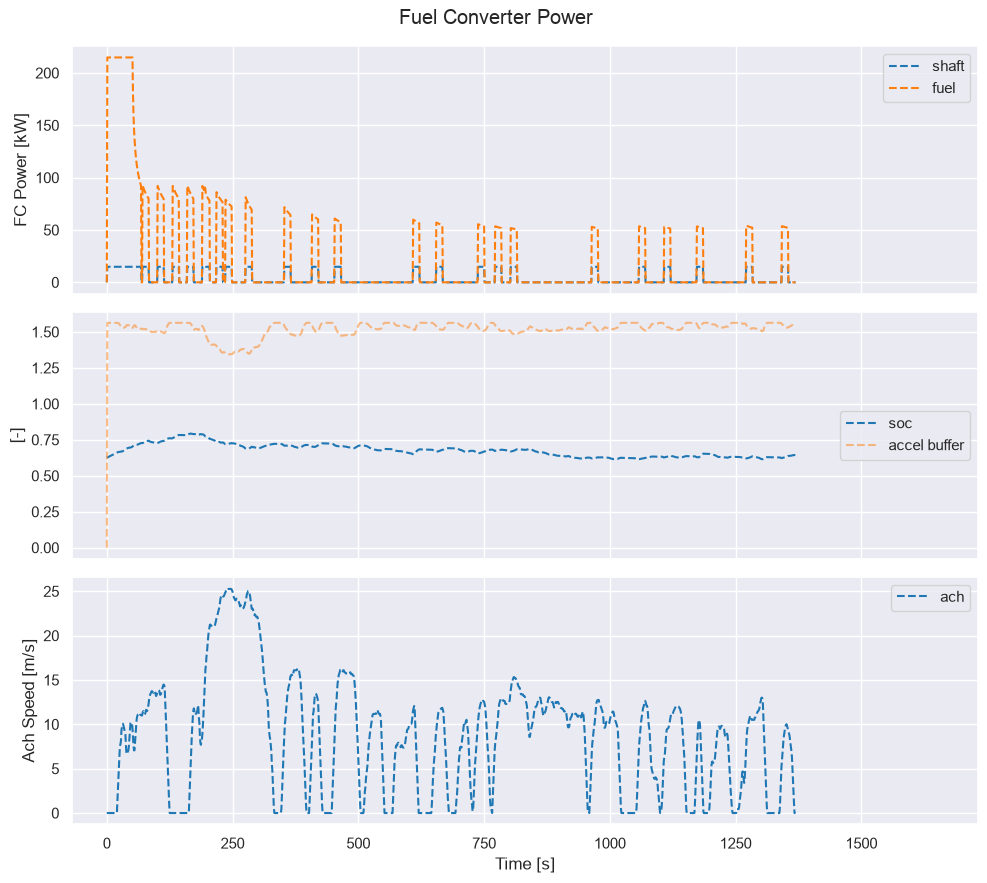

In [6]:
fig_fc_pwr, ax_fc_pwr = plot_hev_fc_pwr(df, save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)

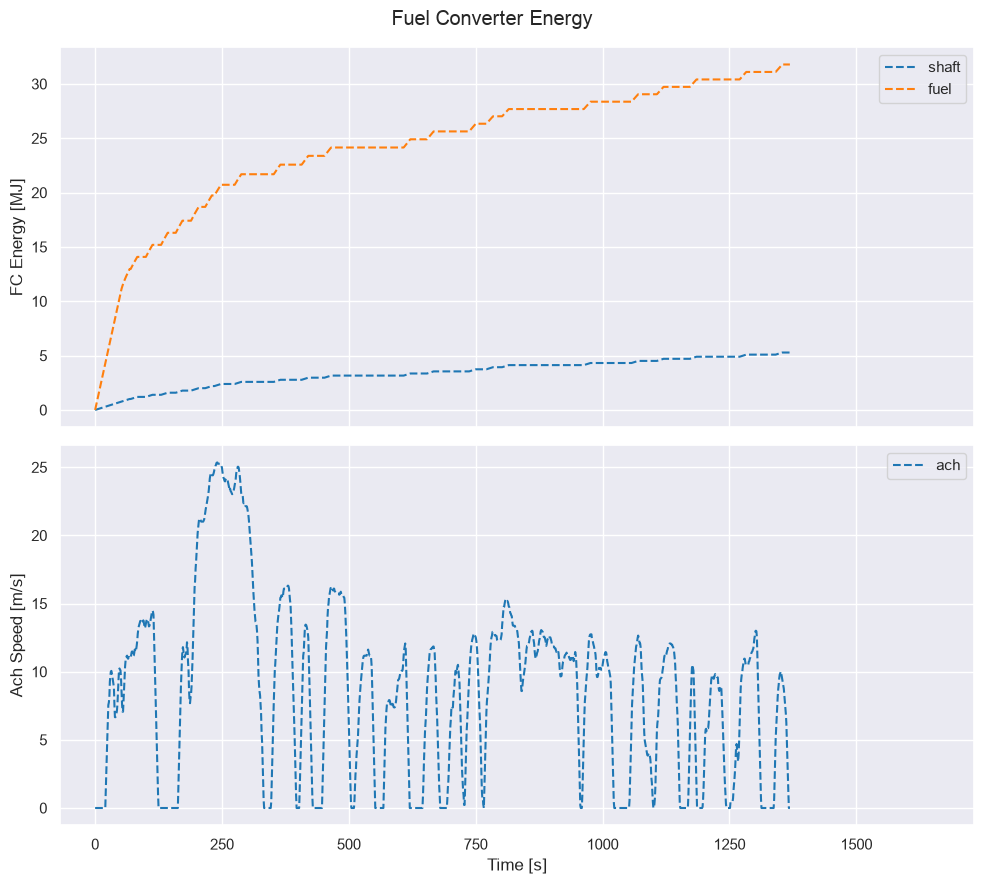

In [7]:
fig_fc_energy, ax_fc_energy = plot_hev_fc_energy(df, save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)

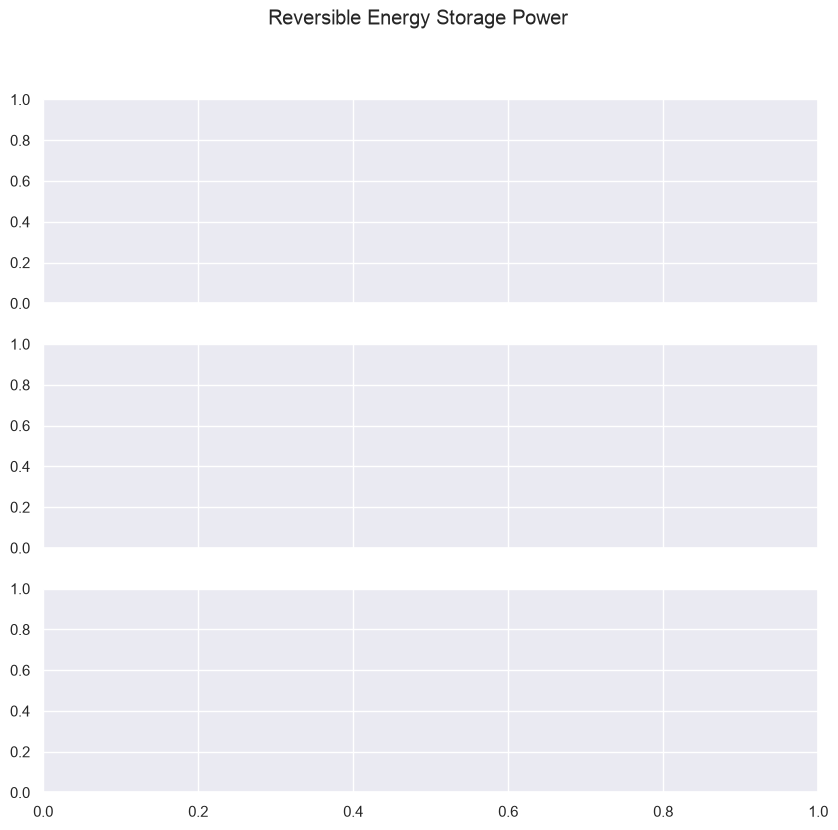

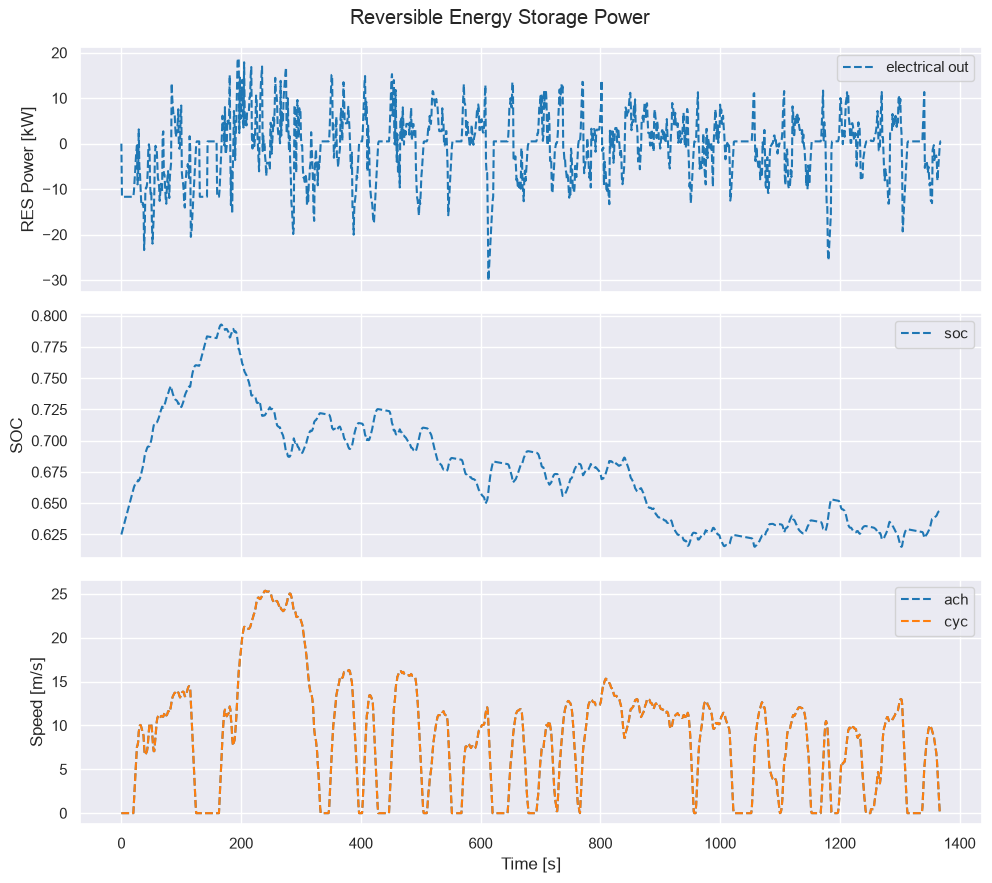

In [8]:
fig_res_pwr, ax_res_pwr = plot_hev_res_pwr(df, save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)

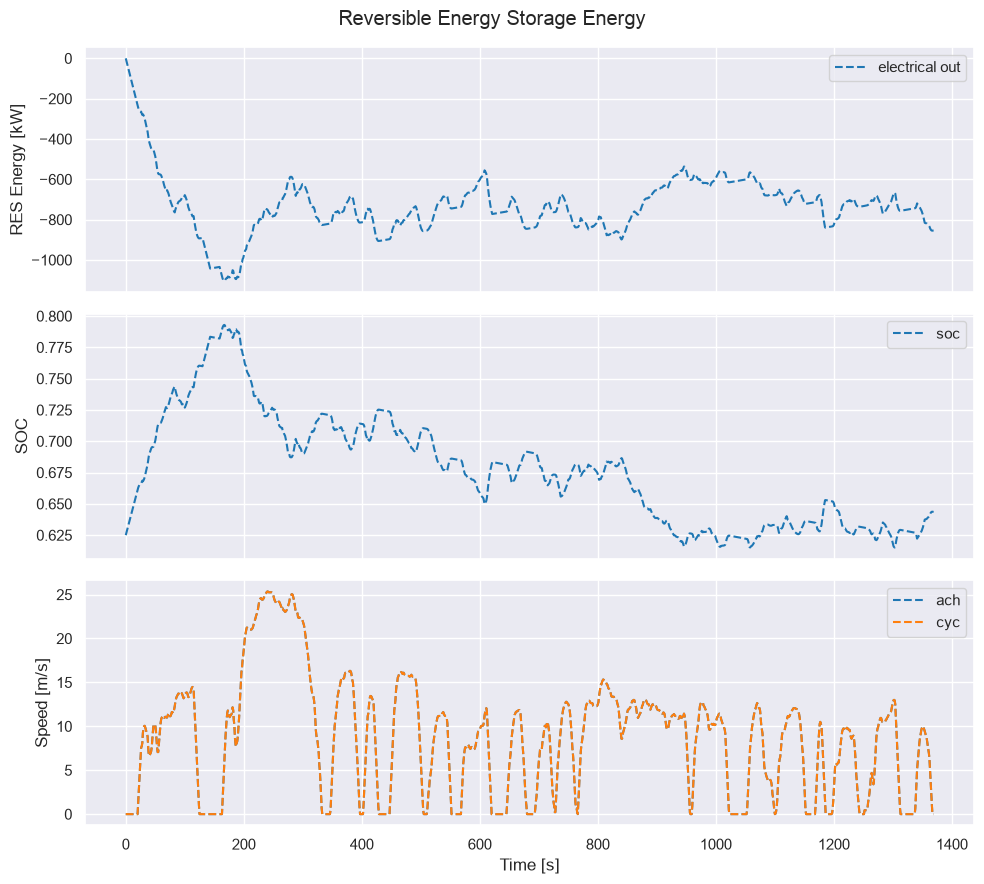

In [9]:
fig_res_energy, ax_res_energy = plot_hev_res_energy(df, save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)

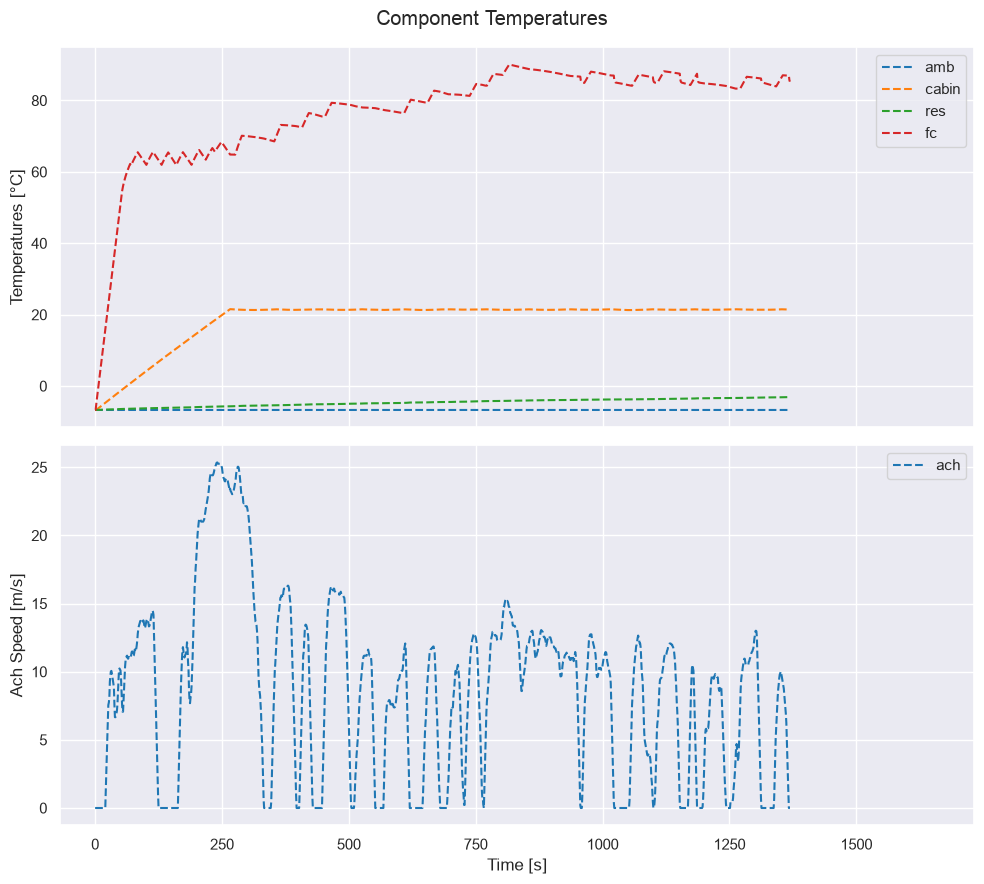

In [10]:
fig_temps, ax_temps = plot_hev_temperatures(df, save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)

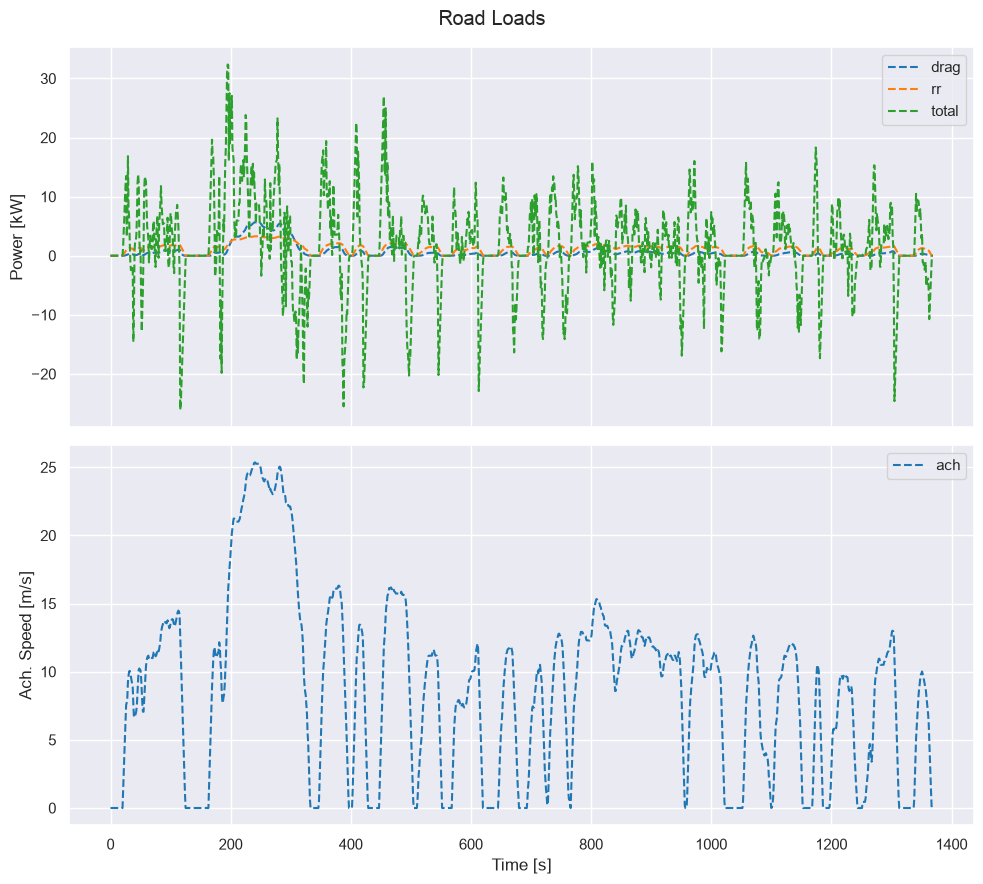

In [11]:
fig, ax = plot_road_loads(df, veh, save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)